Cell 1 – Imports and data

In [49]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import confusion_matrix

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,
                                                    random_state=42,stratify=y)


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


Cell 2 – Dataset info and visualising two features

Features shape: (569, 30)
Classes: ['malignant' 'benign']
Class counts: [212 357]


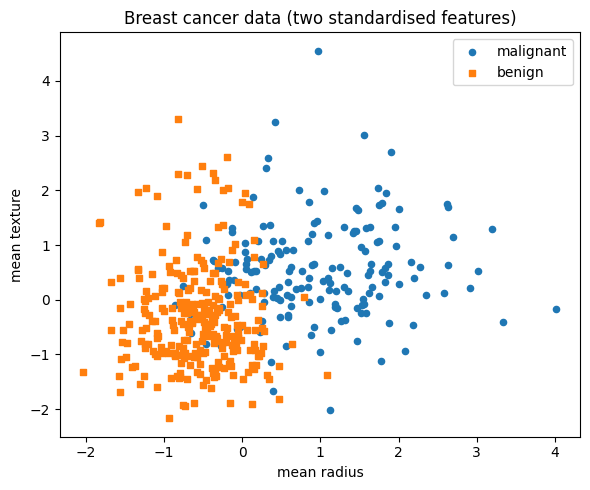

In [50]:
print("Features shape:", X.shape)
print("Classes:", target_names)
print("Class counts:", np.bincount(y))

feat_x = 0
feat_y = 1

plt.figure(figsize=(6, 5))
for label, marker, color in zip([0, 1], ['o', 's'], ['#1f77b4', '#ff7f0e']):
    plt.scatter(X_train_sc[y_train == label, feat_x],
                X_train_sc[y_train == label, feat_y],marker=marker,c=color,
                s=20,label=data.target_names[label])

plt.xlabel(feature_names[feat_x])
plt.ylabel(feature_names[feat_y])
plt.title("Breast cancer data (two standardised features)")
plt.legend()
plt.tight_layout()
plt.show()

Cell 3 – Decision Tree

In [51]:
import time
import pickle

dt = DecisionTreeClassifier(random_state=42)

start = time.time()
dt.fit(X_train_sc, y_train)
train_time_dt = time.time() - start

start = time.time()
y_pred_dt = dt.predict(X_test_sc)
pred_time_dt = time.time() - start

acc_dt = accuracy_score(y_test, y_pred_dt)

size_dt = len(pickle.dumps(dt))

print(f"Decision Tree accuracy: {acc_dt:.3f}")
print(f"DT train time: {train_time_dt:.4f} s")
print(f"DT predict time: {pred_time_dt:.4f} s")
print(f"DT size (bytes): {size_dt}")
print("\nDecision Tree classification report:")
print(classification_report(y_test, y_pred_dt, target_names=target_names))


Decision Tree accuracy: 0.912
DT train time: 0.0279 s
DT predict time: 0.0008 s
DT size (bytes): 4104

Decision Tree classification report:
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



Cell 4 – Random Forest

In [52]:
rf = RandomForestClassifier(n_estimators=200,max_depth=None,random_state=42)

start = time.time()
rf.fit(X_train_sc, y_train)
train_time_rf = time.time() - start

start = time.time()
y_pred_rf = rf.predict(X_test_sc)
pred_time_rf = time.time() - start

acc_rf = accuracy_score(y_test, y_pred_rf)

size_rf = len(pickle.dumps(rf))

print(f"Random Forest accuracy: {acc_rf:.3f}")
print(f"RF train time: {train_time_rf:.4f} s")
print(f"RF predict time: {pred_time_rf:.4f} s")
print(f"RF size (bytes): {size_rf}")
print("\nRandom Forest classification report:")
print(classification_report(y_test, y_pred_rf, target_names=target_names))


Random Forest accuracy: 0.956
RF train time: 0.6872 s
RF predict time: 0.0141 s
RF size (bytes): 634547

Random Forest classification report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Cell 5 – Accuracy summary

In [53]:
print("Model accuracies on breast_cancer data:")
print(f"Decision Tree : {acc_dt:.3f}")
print(f"Random Forest : {acc_rf:.3f}")


Model accuracies on breast_cancer data:
Decision Tree : 0.912
Random Forest : 0.956


Cell 6 – Confusion matrices

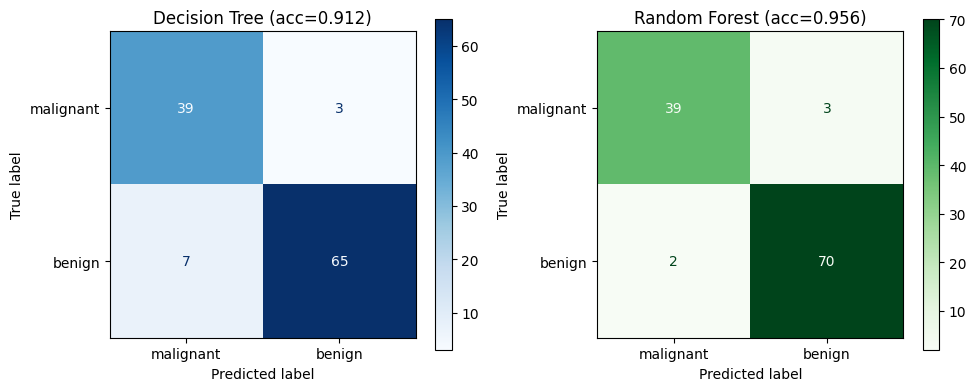

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt,
                                        display_labels=target_names,
                                        ax=axes[0], cmap="Blues")
axes[0].set_title(f"Decision Tree (acc={acc_dt:.3f})")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
                                        display_labels=target_names,
                                        ax=axes[1], cmap="Greens")
axes[1].set_title(f"Random Forest (acc={acc_rf:.3f})")

plt.tight_layout()
plt.show()


Cell 7 – Bar chart: accuracy vs error

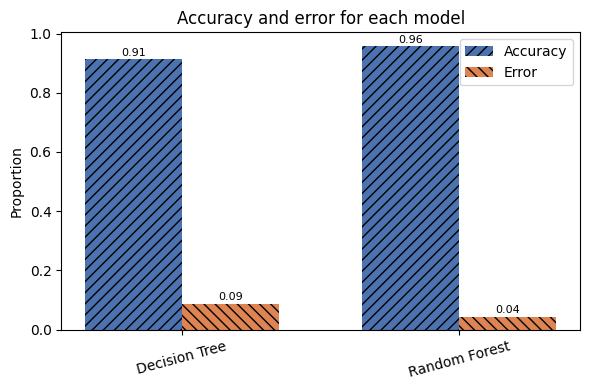

In [55]:
models = ["Decision Tree", "Random Forest"]
accuracies = [acc_dt, acc_rf]
errors = [1 - acc_dt, 1 - acc_rf]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.bar(x - width/2, accuracies, width,
               label="Accuracy",
               color="#4c72b0", hatch="///")
bars2 = ax.bar(x + width/2, errors, width,
               label="Error",
               color="#dd8452", hatch="\\\\\\")

ax.set_ylabel("Proportion")
ax.set_title("Accuracy and error for each model")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

for b in bars1 + bars2:
    height = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, height + 0.005,
            f"{height:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()